Lecture 15: Regression Evaluation Metrics Overview

Importing Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

Loading the dataset

In [3]:
data = pd.read_csv("datasets/lecture15_StudentsPerformance.csv")
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Dataset Overview

In [4]:
data.shape

(1000, 8)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
data.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Converting Categorical Values into numerical Values

In [7]:
data = pd.get_dummies(data,drop_first=True)

Defining Features And Target

In [8]:
X = data.drop("math score",axis=1)
y = data["math score"]

Spliting Data Into Train And Test

In [9]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)


Training Model 

In [10]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Predicting 

In [11]:
y_pred = model.predict(X_test)

MSE 

In [12]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("MSE : ",mse) 
print("MAE : ",mae) 
print("RMSE : ",rmse) 
print("R2_Score : ",r2) 

MSE :  29.09516986671547
MAE :  4.214763142474848
RMSE :  5.393993869732841
R2_Score :  0.8804332983749565


Visualization : Actual Vs Predicted :-

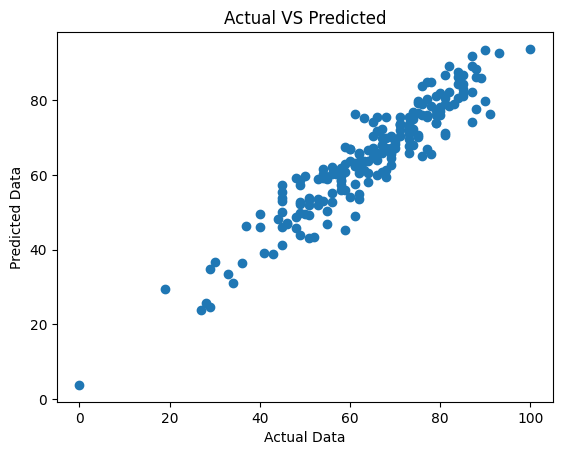

In [13]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Data")
plt.ylabel("Predicted Data")
plt.title("Actual VS Predicted")
plt.show()